# EDA of Superstore Sales


Amid increasing market demands and fierce competition, a prominent superstore chain aims to determine the most effective strategies for boosting their sales. They seek to gain insights into several aspects, including:

-  The overall trend in sales.
-  Monthly sales patterns for each year.
-  Identification of key categories, sub-categories, and products that warrant attention.
-  Target customer segments.
-  Regions and cities that offer potential opportunities or should be approached with caution.

<br><br><br>
## Libraries needed


In [1]:
# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
# Import dataset
df = pd.read_csv(r"C:\Users\artan\Downloads\superstore_final_dataset.csv", encoding='latin1')
df.head()

,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales
0,1,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/6/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold N Roll Cart System,22.3680


In [3]:
# Info of the dataset columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row_ID         9800 non-null   int64  
 1   Order_ID       9800 non-null   object 
 2   Order_Date     9800 non-null   object 
 3   Ship_Date      9800 non-null   object 
 4   Ship_Mode      9800 non-null   object 
 5   Customer_ID    9800 non-null   object 
 6   Customer_Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal_Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product_ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub_Category   9800 non-null   object 
 16  Product_Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [4]:
df.describe()

,Row_ID,Postal_Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [5]:
import pandas as pd
summary_table = df.describe(include='all').transpose()
summary_table['unique'] = df.nunique()
summary_table = summary_table.rename(columns={'50%': 'top', 'freq': 'freq'})
summary_table = summary_table[['count', 'top', 'freq', 'unique']]
print(summary_table)

                count              top      top  freq  unique
Row_ID         9800.0              NaN   4900.5   NaN    9800
Order_ID         9800   CA-2018-100111      NaN    14    4922
Order_Date       9800         5/9/2017      NaN    38    1230
Ship_Date        9800       26/09/2018      NaN    34    1326
Ship_Mode        9800   Standard Class      NaN  5859       4
Customer_ID      9800         WB-21850      NaN    35     793
Customer_Name    9800    William Brown      NaN    35     793
Segment          9800         Consumer      NaN  5101       3
Country          9800    United States      NaN  9800       1
City             9800    New York City      NaN   891     529
State            9800       California      NaN  1946      49
Postal_Code    9789.0              NaN  58103.0   NaN     626
Region           9800             West      NaN  3140       4
Product_ID       9800  OFF-PA-10001970      NaN    19    1861
Category         9800  Office Supplies      NaN  5909       3
Sub_Cate

In [6]:
import pandas as pd
from tabulate import tabulate

summary_table = df.describe(include='all').transpose()

summary_table['unique'] = df.nunique()

summary_table = summary_table.rename(columns={'50%': 'top', 'freq': 'freq'})

summary_table = summary_table[['count', 'top', 'freq', 'unique']]

table_str = tabulate(summary_table, headers='keys', tablefmt='pretty')

print(table_str)


+---------------+--------+-----------------+--------------------+------+--------+
|               | count  |       top       |        top         | freq | unique |
+---------------+--------+-----------------+--------------------+------+--------+
|    Row_ID     | 9800.0 |       nan       |       4900.5       | nan  |  9800  |
|   Order_ID    |  9800  | CA-2018-100111  |        nan         |  14  |  4922  |
|  Order_Date   |  9800  |    5/9/2017     |        nan         |  38  |  1230  |
|   Ship_Date   |  9800  |   26/09/2018    |        nan         |  34  |  1326  |
|   Ship_Mode   |  9800  | Standard Class  |        nan         | 5859 |   4    |
|  Customer_ID  |  9800  |    WB-21850     |        nan         |  35  |  793   |
| Customer_Name |  9800  |  William Brown  |        nan         |  35  |  793   |
|    Segment    |  9800  |    Consumer     |        nan         | 5101 |   3    |
|    Country    |  9800  |  United States  |        nan         | 9800 |   1    |
|     City      

In [7]:
df['Ship_Mode'].value_counts()

Ship_Mode
Standard Class    5859
Second Class      1902
First Class       1501
Same Day           538
Name: count, dtype: int64

In [8]:
df['Segment'].value_counts()

Segment
Consumer       5101
Corporate      2953
Home Office    1746
Name: count, dtype: int64

In [9]:
city = df['City'].value_counts().head(10)
region = df['Region'].value_counts()

print('-----Info City-----')
print(city)
print('\n')
print('-----Info Region-----')
print(region)

-----Info City-----
City
New York City    891
Los Angeles      728
Philadelphia     532
San Francisco    500
Seattle          426
Houston          374
Chicago          308
Columbus         221
San Diego        170
Springfield      161
Name: count, dtype: int64


-----Info Region-----
Region
West       3140
East       2785
Central    2277
South      1598
Name: count, dtype: int64


In [10]:
category = df['Category'].value_counts()
s_category = df['Sub_Category'].value_counts()

print('-----Info Category-----')
print(category)
print('\n')
print('-----Info Sub Category-----')
print(s_category)

-----Info Category-----
Category
Office Supplies    5909
Furniture          2078
Technology         1813
Name: count, dtype: int64


-----Info Sub Category-----
Sub_Category
Binders        1492
Paper          1338
Furnishings     931
Phones          876
Storage         832
Art             785
Accessories     756
Chairs          607
Appliances      459
Labels          357
Tables          314
Envelopes       248
Bookcases       226
Fasteners       214
Supplies        184
Machines        115
Copiers          66
Name: count, dtype: int64


In [11]:
pd.pivot_table(df, values='Sales',index='Region').style.format('${0:,.2f}')

,Sales
Region,
Central,$216.36
East,$240.40
South,$243.52
West,$226.18


In [12]:
pd.pivot_table(df, values='Sales',index='Sub_Category').style.format('${0:,.2f}')

,Sales
Sub_Category,
Accessories,$217.18
Appliances,$227.93
Art,$34.02
Binders,$134.07
Bookcases,$503.60
Chairs,$531.83
Copiers,"$2,215.88"
Envelopes,$65.03
Fasteners,$14.03


In [13]:
pd.pivot_table(df, values='Sales',index='Segment').style.format('${0:,.2f}')

,Sales
Segment,
Consumer,$225.07
Corporate,$233.15
Home Office,$243.40


<br><br><br>
## Data Cleansing

In [14]:
# Check the missing values
df.isna().sum()

Row_ID            0
Order_ID          0
Order_Date        0
Ship_Date         0
Ship_Mode         0
Customer_ID       0
Customer_Name     0
Segment           0
Country           0
City              0
State             0
Postal_Code      11
Region            0
Product_ID        0
Category          0
Sub_Category      0
Product_Name      0
Sales             0
dtype: int64

In [15]:
# Drop the missing values in Postal_Code
df = df.dropna(subset=['Postal_Code'])

In [16]:
# Convert data types so data is accurate
df['Order_Date'] = pd.to_datetime(df['Order_Date'], errors='coerce')
df['Ship_Date'] = pd.to_datetime(df['Ship_Date'], errors='coerce')
df['Postal_Code'] = pd.to_numeric(df['Postal_Code'], errors='coerce').astype('Int64')
df['Sales'] = pd.to_numeric(df['Sales'], errors='coerce')

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9789 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row_ID         9789 non-null   int64         
 1   Order_ID       9789 non-null   object        
 2   Order_Date     3955 non-null   datetime64[ns]
 3   Ship_Date      3811 non-null   datetime64[ns]
 4   Ship_Mode      9789 non-null   object        
 5   Customer_ID    9789 non-null   object        
 6   Customer_Name  9789 non-null   object        
 7   Segment        9789 non-null   object        
 8   Country        9789 non-null   object        
 9   City           9789 non-null   object        
 10  State          9789 non-null   object        
 11  Postal_Code    9789 non-null   Int64         
 12  Region         9789 non-null   object        
 13  Product_ID     9789 non-null   object        
 14  Category       9789 non-null   object        
 15  Sub_Category   9789 non-nu

In [17]:
# Round the 'Sales' column to two decimal places
df['Sales'] = df['Sales'].round(2)
df.head(5)


,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales
0,1,CA-2017-152156,2017-08-11,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96
1,2,CA-2017-152156,2017-08-11,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94
2,3,CA-2017-138688,2017-12-06,NaT,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62
3,4,US-2016-108966,2016-11-10,NaT,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.58
4,5,US-2016-108966,2016-11-10,NaT,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold N Roll Cart System,22.37


<br><br><br>
# EDA and Data Visualization

In [18]:
import pandas as pd

# Copy the table in case of any unwanted changes
df2 = df.copy()
df2.head(5)

,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales
0,1,CA-2017-152156,2017-08-11,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96
1,2,CA-2017-152156,2017-08-11,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94
2,3,CA-2017-138688,2017-12-06,NaT,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62
3,4,US-2016-108966,2016-11-10,NaT,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.58
4,5,US-2016-108966,2016-11-10,NaT,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold N Roll Cart System,22.37


<br><br><br>
## Total Sales 2015-2018

#### It is important to know the actual total of all sales that happened between 2015-2018 to ensure consistency with following numbers


In [19]:
# Total sales 2015 - 2018
total_sales = df2['Sales'].sum()
print(f'Total Sales: ${total_sales:.2f}')


Total Sales: $2252607.18


<br><br><br>
## Total Sales by Year

#### We break down the total sales by the year to analyze what years were most profitable 

C:\Users\artan\AppData\Local\Temp\ipykernel_8836\3788949528.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=sales_by_year, x='Year', y='Sales', estimator=sum, errorbar=None,palette=colors)


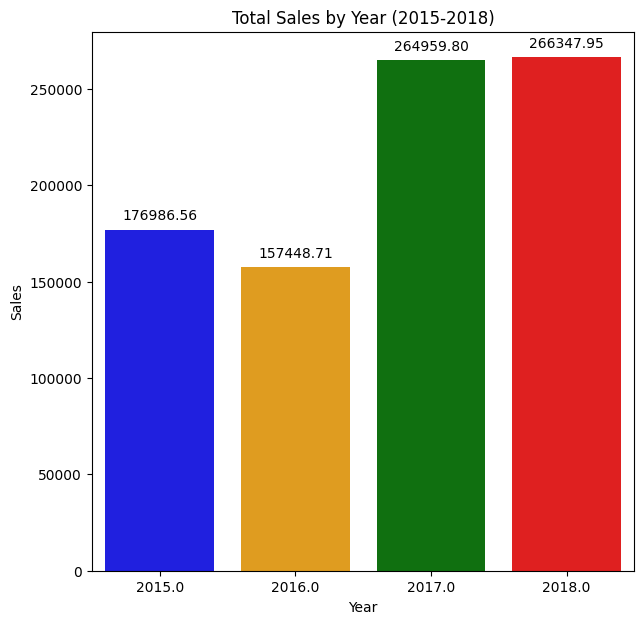

In [29]:
# Define year for date-time
df2['Year'] = df2['Order_Date'].dt.year

# Filter the data for the years 2015 to 2018
sales_by_year = df2[df2['Year'].between(2015, 2018)]

colors = ['blue', 'orange', 'green', 'red']
# Bar plot
plt.figure(figsize=(7, 7))
ax = sns.barplot(data=sales_by_year, x='Year', y='Sales', estimator=sum, errorbar=None,palette=colors)
plt.title('Total Sales by Year (2015-2018)')
plt.xlabel('Year')
plt.ylabel('Sales')

# Add labels on top of the bars
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.2f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')
plt.show()




#### -  2018 was had the highest sales by far, 2016 was the lowest.

<br><br><br>
## Category count

#### Now we have to identify the categories and their total count to begin to drill down into subcategories to measure product performance 

C:\Users\artan\AppData\Local\Temp\ipykernel_8836\3702231778.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='Category',palette=colors)


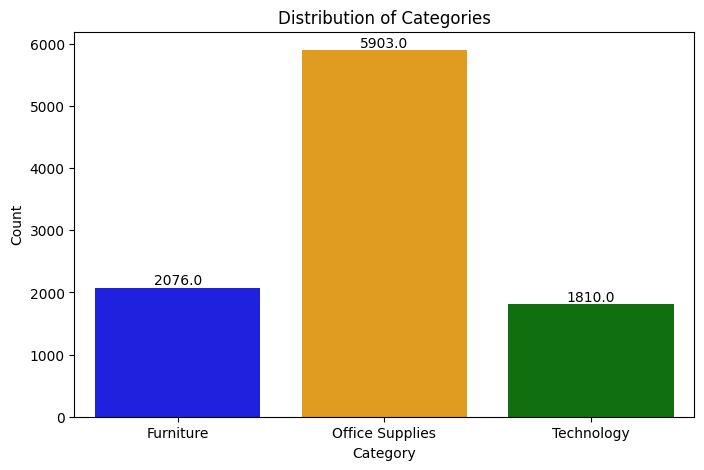

In [44]:
# bar chart
plt.figure(figsize=(8, 5))
colors = ['blue', 'orange', 'green']
ax = sns.countplot(data=df, x='Category',palette=colors)
plt.title('Distribution of Categories')
plt.xlabel('Category')
plt.ylabel('Count')

# Annotate the bars with count values
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom')
import seaborn as sns
import matplotlib.pyplot as plt


plt.show()



#### -  Office supplies has the highest count of orders placed while Technology has the lowest. Let's see how that goes when it comes to total       sales.

<br><br><br>
## Category Sales

#### We now find the distribution of sales between categories

C:\Users\artan\AppData\Local\Temp\ipykernel_8836\2107202909.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df, x='Category', y='Sales', estimator=sum, errorbar=None,palette=colors)


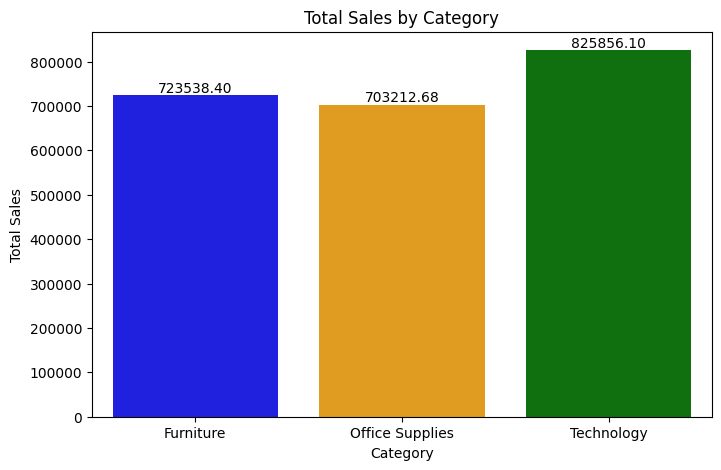

In [45]:
# Bar chart
plt.figure(figsize=(8, 5))
colors = ['blue', 'orange', 'green']
ax = sns.barplot(data=df, x='Category', y='Sales', estimator=sum, errorbar=None,palette=colors)
plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')

# Annotate the bars with count values
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom')
    
plt.show()


#### -  Technology has the most sales, but the other two categories are not too far behind.

<br><br><br>
## Subcategory Sales

#### After finding the sales between categories, we can break it down even further to subcategories. This will then lead us into individual product performance once we drill down further.

C:\Users\artan\AppData\Local\Temp\ipykernel_4604\3505619943.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=subcategory_sales, x='Sales', y='Sub_Category', palette='Set1', errorbar=None)


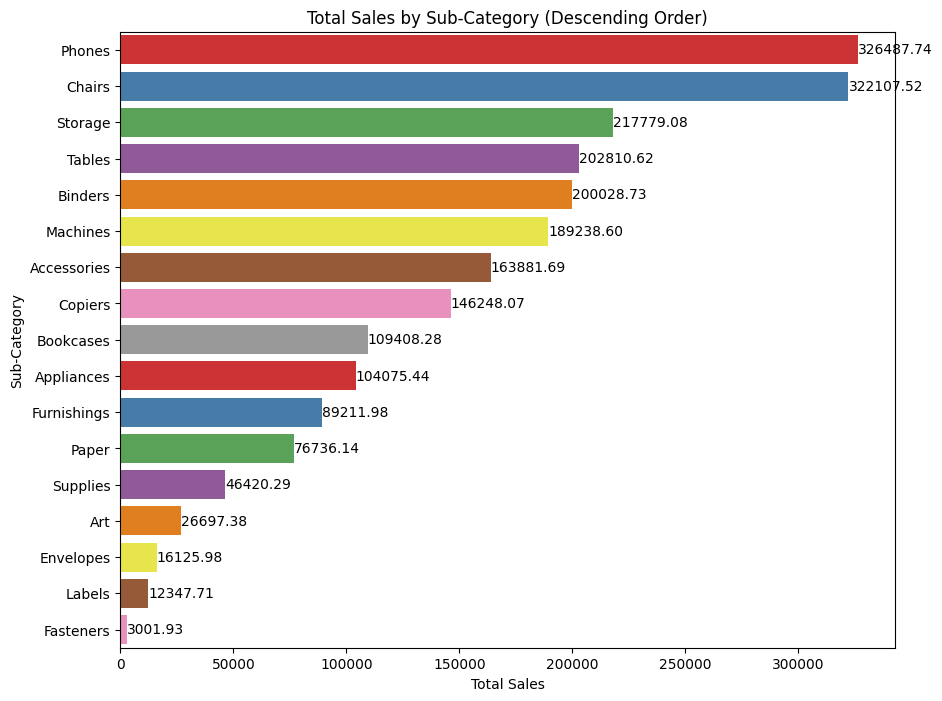

In [23]:
# Calculate total sales for each subcategory
subcategory_sales = df2.groupby('Sub_Category')['Sales'].sum().reset_index()

# Sort the data frame by total sales in descending order
subcategory_sales = subcategory_sales.sort_values(by='Sales', ascending=False)

# Bar chart 
plt.figure(figsize=(10, 8))
ax = sns.barplot(data=subcategory_sales, x='Sales', y='Sub_Category', palette='Set1', errorbar=None)
plt.title('Total Sales by Sub-Category (Descending Order)')
plt.xlabel('Total Sales')
plt.ylabel('Sub-Category')

# Annotate the bars with total sales 
for p in ax.patches:
    ax.annotate(f'{p.get_width():.2f}', (p.get_width(), p.get_y() + p.get_height() / 2.), ha='left', va='center', fontsize=10)

plt.show()




#### -  Phones and chairs are the highest selling sub-category while art, envelopes, labels, and fasteners are significantly lower. 

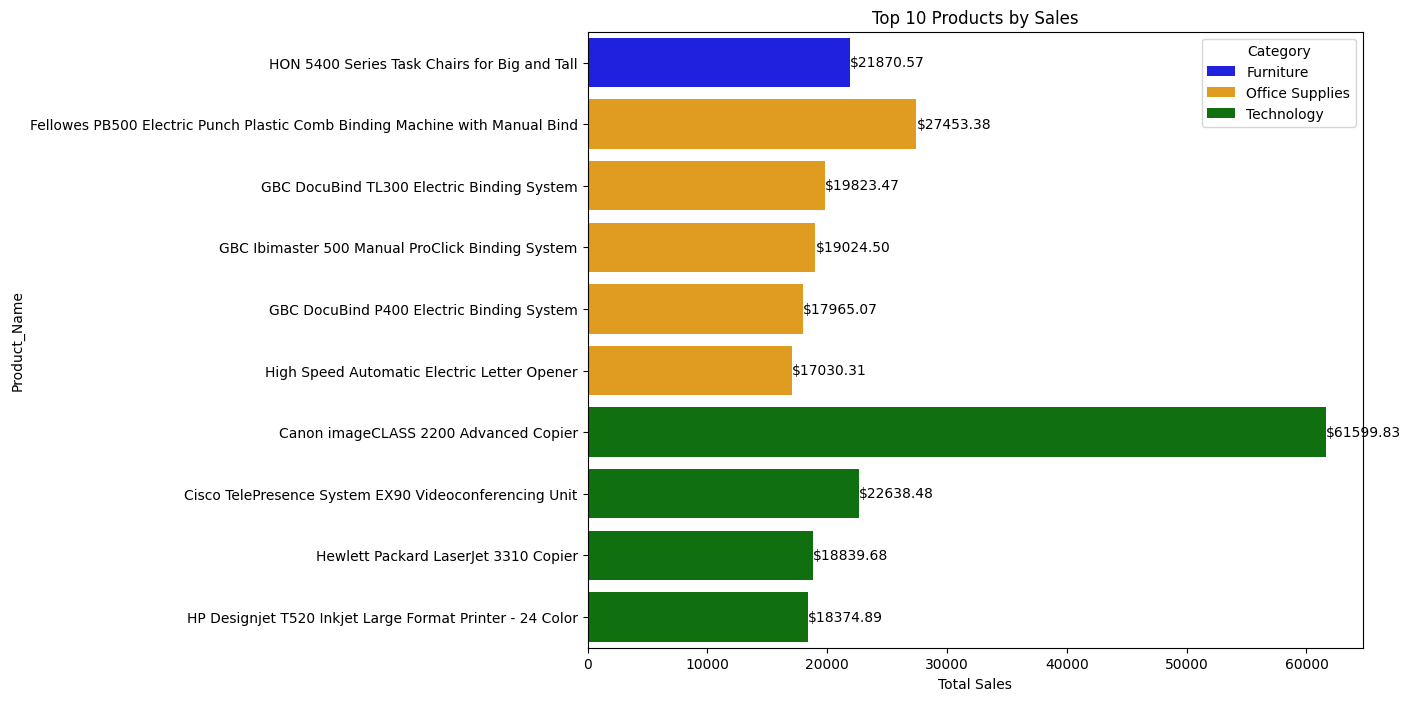

In [50]:
product_sales = df2.groupby(['Category', 'Product_Name'])['Sales'].sum().reset_index()

# Calculate total sales for each product
top_10_products = product_sales.sort_values(by='Sales', ascending=False).head(10)

# Sort the top 10 products by category
top_10_products = top_10_products.sort_values(by=['Category', 'Sales'], ascending=[True, False])

# Take the top 10 products 
top_10_products = product_sales.sort_values('Category').head(10)
# Define colors palette for each category
category_colors = {
    'Furniture': 'blue',
    'Office Supplies': 'orange',
    'Technology': 'green'
}

# Create a horizontal bar chart
plt.figure(figsize=(10, 8))
sns.barplot(data=top_10_products, x='Sales', y='Product_Name', hue='Category', palette=category_colors)
plt.title('Top 10 Products by Sales')
plt.xlabel('Total Sales')
plt.ylabel('Product_Name')

# Annotate the bars with total sales values
for index, value in enumerate(top_10_products['Sales']):
    plt.text(value, index, f'${value:.2f}', va='center')

plt.show()


<br><br><br>
## Customer Segmentation

#### -  Let's explore customer segmentation 

C:\Users\artan\AppData\Local\Temp\ipykernel_8836\771515416.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df, x='Segment', y='Sales', estimator=sum, errorbar=None,palette=colors)


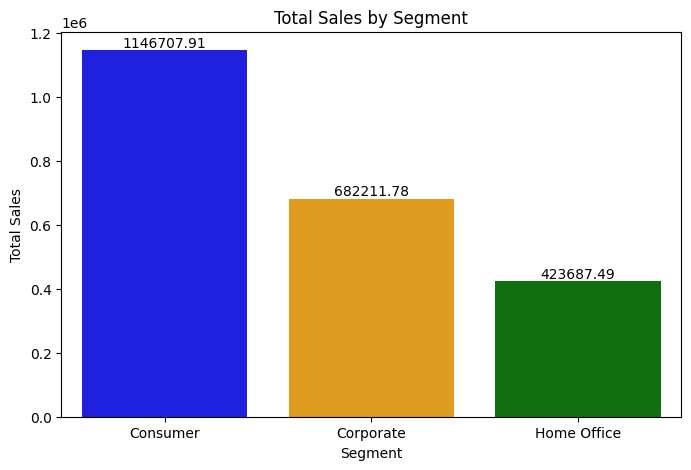

In [46]:
# bar chart
plt.figure(figsize=(8, 5))
colors = ['blue', 'orange', 'green']
ax = sns.barplot(data=df, x='Segment', y='Sales', estimator=sum, errorbar=None,palette=colors)
plt.title('Total Sales by Segment')
plt.xlabel('Segment')
plt.ylabel('Total Sales')

# Annotate the bars with count values
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom')
    
plt.show()

#### -  Consumer segment wins by a very large margin ~50% for total sales 

<br><br><br>
## Sales by Region

C:\Users\artan\AppData\Local\Temp\ipykernel_8836\2721365488.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df, x='Region', y='Sales', estimator=sum, errorbar=None,palette=colors)


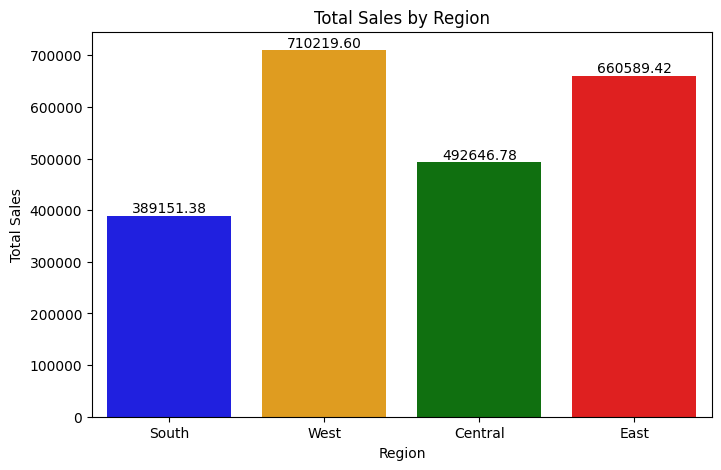

In [47]:
# bar chart
plt.figure(figsize=(8, 5))
colors = ['blue', 'orange', 'green', 'red']
ax = sns.barplot(data=df, x='Region', y='Sales', estimator=sum, errorbar=None,palette=colors)
plt.title('Total Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales')

# Annotate the bars with count values
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom')
    
plt.show()


#### -  The West region has the highest sales total followed by the East. Let's see which cities make up the most or each regional sales

<br><br><br>
## Top 10 Cities for Sales

#### -  Identify the top ten to focus on cities to target. First we need to list what city belongs to what region and then show the top 10 sales by city

       Central           East         South             West
0      Houston  New York City  Jacksonville      Los Angeles
1      Chicago   Philadelphia       Atlanta          Seattle
2      Detroit         Newark   Springfield    San Francisco
3  San Antonio       Lakewood     Henderson        San Diego
4       Dallas     Providence      Columbus           Denver
5    Lafayette       Columbus     Arlington          Phoenix
6  Minneapolis       Columbia     Charlotte  North Las Vegas
7      Jackson      Lancaster    Burlington           Fresno
8  Springfield        Buffalo      Richmond       Sacramento
9    Milwaukee     Long Beach      Columbia           Tucson


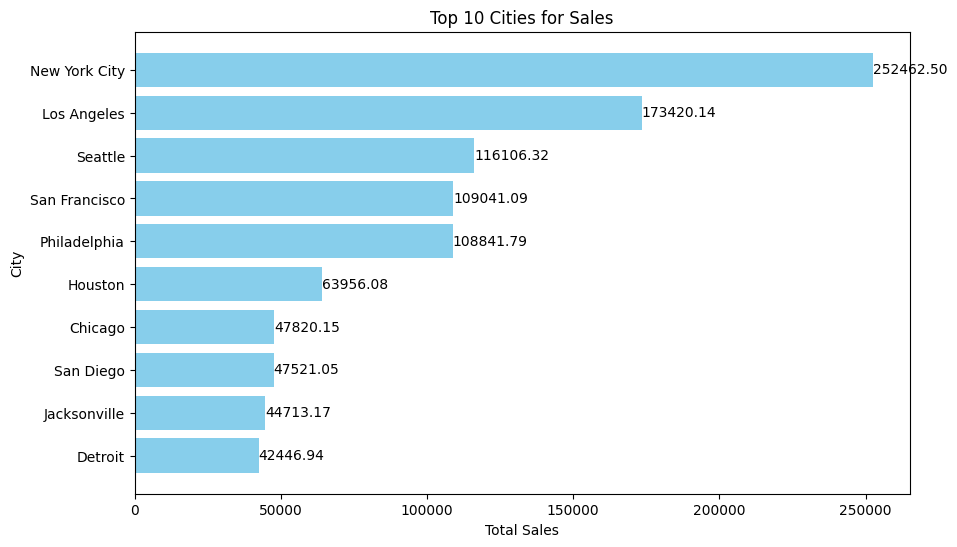

In [26]:
# Calculate total sales for each city
city_sales = df2.groupby(['Region', 'City'])['Sales'].sum().reset_index()

# Sort the cities by total sales in descending order within each region
city_sales = city_sales.sort_values(by=['Region', 'Sales'], ascending=[True, False])

# Create a dictionary to store the top 10 cities for each region
top_cities_by_region = {}

# Iterate through each region and select the top 10 cities
for region, data in city_sales.groupby('Region'):
    top_cities_by_region[region] = data.head(10)['City'].tolist()

# Text table
text_table = pd.DataFrame.from_dict(top_cities_by_region, orient='index').transpose()

# Display the text table
print(text_table)



# Calculate total sales for each city
city_sales = df2.groupby('City')['Sales'].sum().reset_index()

# Sort the cities by total sales in descending order
city_sales = city_sales.sort_values(by='Sales', ascending=False)

# Take the top 10 cities
top_10_cities = city_sales.head(10)

# Bar chart 
plt.figure(figsize=(10, 6))
plt.barh(top_10_cities['City'], top_10_cities['Sales'], color='skyblue')
plt.title('Top 10 Cities for Sales')
plt.xlabel('Total Sales')
plt.ylabel('City')

# Annotate the bars with total sales values
for index, value in enumerate(top_10_cities['Sales']):
    plt.text(value, index, f'{value:.2f}', va='center')

plt.gca().invert_yaxis()  
plt.show()



#### -  West cities lead with 4 cities (Los Angeles, Seattle, San Francisco, and San Diego) for a total of ~67% (446,088.60) of West Sales

#### -  East cities (New york City and Phildelphia) on this top 10 list for sales account for ~55% (361,304.29) of the East total sales

#### -  Superstore should target in the West and East regions, specifically the cities litsed above

<br><br><br>
## Bottom 10 cities for sales

#### -  Identify the bottom 10 to avoid  

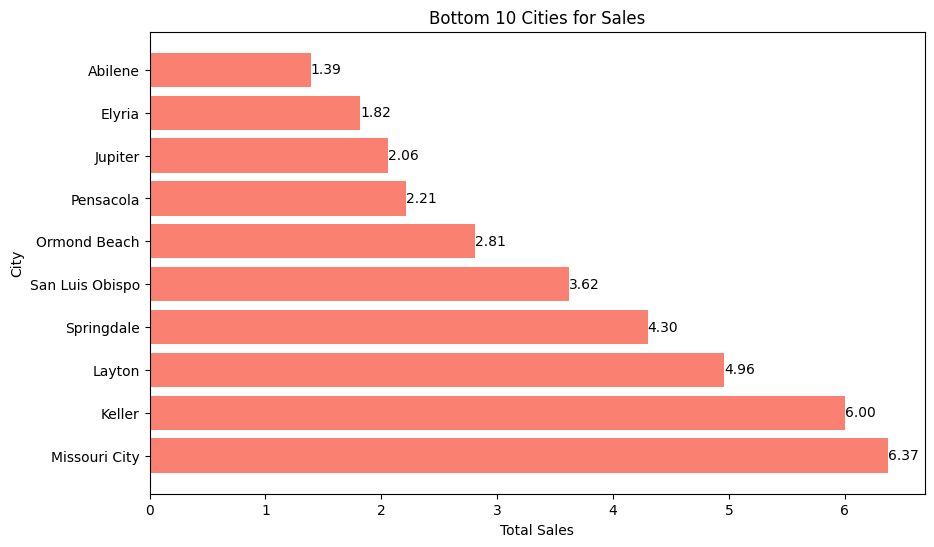

In [27]:
# Calculate total sales for each city
city_sales = df2.groupby('City')['Sales'].sum().reset_index()

# Sort the cities by total sales in ascending order (to get the bottom 10)
city_sales = city_sales.sort_values(by='Sales', ascending=True)

# Take the bottom 10 cities
bottom_10_cities = city_sales.head(10)

# Bar chart 
plt.figure(figsize=(10, 6))
plt.barh(bottom_10_cities['City'], bottom_10_cities['Sales'], color='salmon')
plt.title('Bottom 10 Cities for Sales')
plt.xlabel('Total Sales')
plt.ylabel('City')

# Annotate the bars with total sales values
for index, value in enumerate(bottom_10_cities['Sales']):
    plt.text(value, index, f'{value:.2f}', va='center')

plt.gca().invert_yaxis()  
plt.show()



#### -  When looking at the city sales data, there is a very large gap between the top 10 and the bottom 10. 

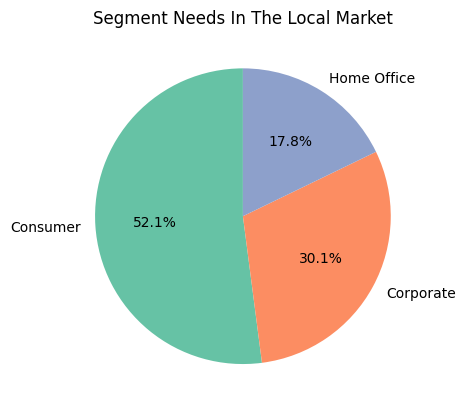

In [28]:
segment = ['Consumer', 'Corporate', 'Home Office']
segment_count = df['Segment'].value_counts()

plt.pie(segment_count, labels = segment, autopct ='%1.1f%%' ,startangle = 90, colors = sns.color_palette('Set2'))
plt.title('Segment Needs In The Local Market')
plt.show()

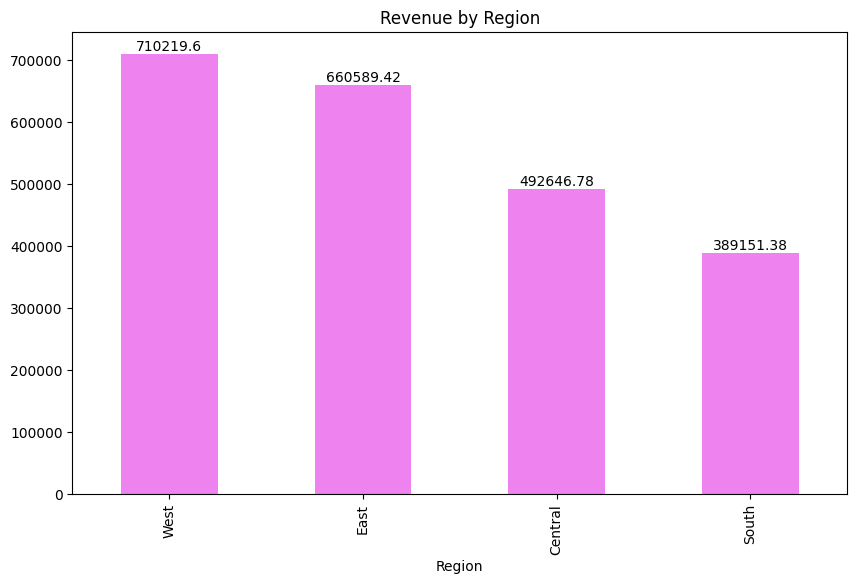

In [29]:
count_sales = region = df.groupby('Region')['Sales'].sum()
region = count_sales.sort_values(ascending=False)
region_name = ['West', 'East','Central','South']

plt.figure(figsize = (10,6))
region.plot(kind = 'bar', color = 'violet')
plt.xlabel('Region')
plt.title("Revenue by Region")

for x, y in enumerate(region):
    plt.text(x, y + 10, str(y), ha = 'center', va = 'bottom')
plt.show()

Text(0.5, 1.0, "Revenue by Region '%'")

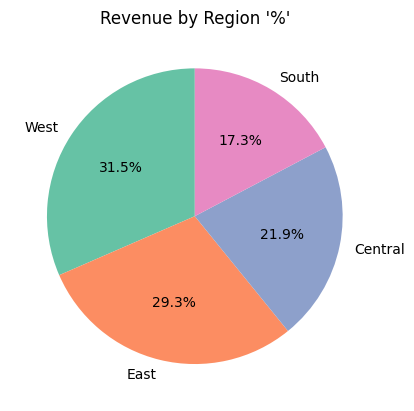

In [30]:
plt.pie(region, labels = region_name, autopct='%1.1f%%', startangle = 90, colors = sns.color_palette('Set2'))
plt.title("Revenue by Region '%'")

<br><br><br>
## Insights

### - After conducting a thorough analysis, we have drawn several significant conclusions that can offer valuable insights for our business strategy:
<br>
 -  Sales Trend: Our sales exhibit a consistent peak at the end and beginning of each year. To leverage this seasonal pattern, we suggest running targeted promotions and discounts during these transitional periods. This approach can further enhance sales and take advantage of heightened customer demand.
<br>
 -   Product Analysis: The list of top ten best-selling products has shown remarkable consistency over time, as has the performance of the lowest-performing products. To enhance our product portfolio, we recommend retaining the best-sellers while delving deeper into the underperforming ones. This investigation may encompass efforts to identify potential enhancements or explore the possibility of substituting them with more in-demand alternatives. Our primary focus should be on the Technology sub-category, with special attention to Phones and Chairs, given their exceptional sales performance.
<br>
 -   Segmentation Impact: Our analysis of customer segmentation based on classification (Company, Customer, Home Office) has revealed distinct sales patterns. To cater to the unique needs of each segment, we advise customizing marketing campaigns and product promotions. This approach can maximize customer engagement and retention.
<br>
-   Regional Variation: Significant variations in sales across regions have come to our attention. To gain a deeper understanding of the underlying factors, we recommend conducting thorough investigations to pinpoint elements that may be influencing these differences. By tailoring marketing strategies and product offerings to align with regional preferences, we can potentially increase sales and enhance customer satisfaction by focusing on West and East cities and avoiding the cities in the bottom 10 list.
<br>



### By implementing these suggestions, we aim to strengthen our market position, enhance customer satisfaction, and foster sustainable business growth. Continuously monitoring and evaluating the outcomes will be crucial to ensure the effectiveness of our strategies and make timely adjustments when necessary.